In [25]:
#DECODELABS INTERNSHIP - DATA SCIENCE PROJECT 1 - Amashi Fernando
#Advanced EDA & Feature Engineering
#Dataset: Online Store Orders


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
#LOADING DATA
df = pd.read_excel("Dataset-online_store_orders.xlsx")

In [28]:
print(f"\nShape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nFirst 5 Rows:\n{df.head()}")
print(f"\nBasic Statistics:\n{df.describe()}")


Shape: (1200, 14)

Columns: ['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

Data Types:
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

First 5 Rows:
     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet      

In [29]:
# Missing Value Analysis

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct.round(2)
})
print(missing_df[missing_df["Missing Count"] > 0])


            Missing Count  Missing %
CouponCode            309      25.75


In [30]:
# Value counts for categorical columns

for col in ["Product", "PaymentMethod", "OrderStatus", "ReferralSource", "CouponCode"]:
    print(f"\n{col}:\n{df[col].value_counts()}")


Product:
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

PaymentMethod:
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

OrderStatus:
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

ReferralSource:
ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

CouponCode:
CouponCode
FREESHIP    313
WINTER15    292
SAVE10      286
Name: count, dtype: int64


* CouponCode has 25.75% missing and this column is  CATEGORICAL type, so KNN (which needs numeric distance) is not appropriate here.

* Missing simply means "customer did not use a coupon" - this is alogical/domain-driven imputation, not a guess.

In [31]:
#Handle missing values

print(f"\nCouponCode missing: {df['CouponCode'].isnull().sum()} rows "
      f"({df['CouponCode'].isnull().mean()*100:.2f}%)")
print("-> Categorical column with structural missingness.")
print("-> Filling missing values with 'No Coupon' (domain logic).")

df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

print(f"Missing after fix: {df['CouponCode'].isnull().sum()}")
print(f"CouponCode value counts:\n{df['CouponCode'].value_counts()}")

# Final check - confirm zero missing values across the whole dataset
print(f"\nTotal missing values remaining in dataset: {df.isnull().sum().sum()}")





CouponCode missing: 309 rows (25.75%)
-> Categorical column with structural missingness.
-> Filling missing values with 'No Coupon' (domain logic).
Missing after fix: 0
CouponCode value counts:
CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64

Total missing values remaining in dataset: 0


In [32]:
# Outlier Detection & Neutralization (IQR Method)

def detect_and_cap_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers_count = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"\n{col}:")
    print(f"  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"  Lower Bound={lower:.2f}, Upper Bound={upper:.2f}")
    print(f"  Outliers Found: {outliers_count}")

    # Winsorization - cap at boundaries instead of deleting rows.
    # This preserves row count and sequential integrity (per the training material: numpy.clip() over row deletion).
    df[col] = np.clip(df[col], lower, upper)
    print(f"  -> Capped using Winsorization (np.clip). Rows preserved.")
    return df

numeric_cols = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]
for col in numeric_cols:
    df = detect_and_cap_outliers(df, col)

print("\nOutlier treatment complete. Row count unchanged:", df.shape[0])


Quantity:
  Q1=2.00, Q3=4.00, IQR=2.00
  Lower Bound=-1.00, Upper Bound=7.00
  Outliers Found: 0
  -> Capped using Winsorization (np.clip). Rows preserved.

UnitPrice:
  Q1=186.06, Q3=521.57, IQR=335.51
  Lower Bound=-317.20, Upper Bound=1024.83
  Outliers Found: 0
  -> Capped using Winsorization (np.clip). Rows preserved.

ItemsInCart:
  Q1=4.00, Q3=7.00, IQR=3.00
  Lower Bound=-0.50, Upper Bound=11.50
  Outliers Found: 0
  -> Capped using Winsorization (np.clip). Rows preserved.

TotalPrice:
  Q1=410.52, Q3=1578.47, IQR=1167.95
  Lower Bound=-1341.41, Upper Bound=3330.41
  Outliers Found: 8
  -> Capped using Winsorization (np.clip). Rows preserved.

Outlier treatment complete. Row count unchanged: 1200


In [33]:
# Feature Engineering (5 New Predictive Features)

# Feature 1: RevenuePerItem - average revenue contributed per unit
df["RevenuePerItem"] = df["TotalPrice"] / df["Quantity"]
print("\nFeature 1 Created: RevenuePerItem = TotalPrice / Quantity")
print(df["RevenuePerItem"].describe())

# Feature 2: HasCoupon - binary flag, did the customer use a coupon?
df["HasCoupon"] = (df["CouponCode"] != "No Coupon").astype(int)
print("\nFeature 2 Created: HasCoupon (1 = Yes, 0 = No)")
print(df["HasCoupon"].value_counts())

# Feature 3: OrderMonth - extract month from Date (seasonality signal)
df["OrderMonth"] = df["Date"].dt.month
print("\nFeature 3 Created: OrderMonth (1=Jan ... 12=Dec)")
print(df["OrderMonth"].value_counts().sort_index())

# Feature 4: OrderYear - extract year from Date
df["OrderYear"] = df["Date"].dt.year
print("\nFeature 4 Created: OrderYear")
print(df["OrderYear"].value_counts())

# Feature 5: IsHighValueOrder - flag orders above median TotalPrice
median_price = df["TotalPrice"].median()
df["IsHighValueOrder"] = (df["TotalPrice"] > median_price).astype(int)
print(f"\nFeature 5 Created: IsHighValueOrder (TotalPrice > median {median_price:.2f})")
print(df["IsHighValueOrder"].value_counts())

print(f"\nAll 5 new features created successfully! New shape: {df.shape}")



Feature 1 Created: RevenuePerItem = TotalPrice / Quantity
count    1200.000000
mean      356.347727
std       197.072468
min        11.390000
25%       186.062500
50%       364.210000
75%       521.570000
max       699.930000
Name: RevenuePerItem, dtype: float64

Feature 2 Created: HasCoupon (1 = Yes, 0 = No)
HasCoupon
1    891
0    309
Name: count, dtype: int64

Feature 3 Created: OrderMonth (1=Jan ... 12=Dec)
OrderMonth
1     106
2     106
3     128
4     113
5     120
6     147
7      87
8      79
9      73
10     78
11     76
12     87
Name: count, dtype: int64

Feature 4 Created: OrderYear
OrderYear
2023    510
2024    459
2025    231
Name: count, dtype: int64

Feature 5 Created: IsHighValueOrder (TotalPrice > median 823.62)
IsHighValueOrder
1    600
0    600
Name: count, dtype: int64

All 5 new features created successfully! New shape: (1200, 19)


* There are nominal categories (no natural order) , So One-Hot Encoding is the correct choice (Label Encoding would create false ordinal distance).

* Dropped ID/free-text columns that hold no predictive value for ML (unique identifiers, raw text addresses, raw date already extracted into OrderMonth/OrderYear)

In [34]:
# Encoding Categorical Variables (One-Hot Encoding)

cols_to_encode = ["Product", "PaymentMethod", "OrderStatus", "ReferralSource", "CouponCode"]
print(f"\nOne-Hot Encoding columns: {cols_to_encode}")

df_encoded = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)


cols_to_drop = ["OrderID", "CustomerID", "ShippingAddress", "TrackingNumber", "Date"]
df_encoded = df_encoded.drop(columns=cols_to_drop)

print(f"\nShape after encoding & dropping ID columns: {df_encoded.shape}")
print(f"\nFinal columns:\n{df_encoded.columns.tolist()}")


One-Hot Encoding columns: ['Product', 'PaymentMethod', 'OrderStatus', 'ReferralSource', 'CouponCode']

Shape after encoding & dropping ID columns: (1200, 30)

Final columns:
['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'RevenuePerItem', 'HasCoupon', 'OrderMonth', 'OrderYear', 'IsHighValueOrder', 'Product_Desk', 'Product_Laptop', 'Product_Monitor', 'Product_Phone', 'Product_Printer', 'Product_Tablet', 'PaymentMethod_Credit Card', 'PaymentMethod_Debit Card', 'PaymentMethod_Gift Card', 'PaymentMethod_Online', 'OrderStatus_Delivered', 'OrderStatus_Pending', 'OrderStatus_Returned', 'OrderStatus_Shipped', 'ReferralSource_Facebook', 'ReferralSource_Google', 'ReferralSource_Instagram', 'ReferralSource_Referral', 'CouponCode_No Coupon', 'CouponCode_SAVE10', 'CouponCode_WINTER15']


In [35]:
# Multicollinearity Check & Removal

numeric_df = df_encoded.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr().abs()

# Isolate upper triangle to avoid checking the same pair twice
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identify any pair with correlation > 0.80
high_corr_pairs = [
    (row, col, corr_matrix.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.80
]

print("\nHighly correlated pairs (> 0.80):")
if high_corr_pairs:
    for row, col, val in high_corr_pairs:
        print(f"  {row} <-> {col}: {val:.3f}")
else:
    print("  None found - no multicollinearity issues in this dataset.")

cols_to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.80)]
if cols_to_drop_corr:
    print(f"\nDropping: {cols_to_drop_corr}")
    df_encoded = df_encoded.drop(columns=cols_to_drop_corr)
else:
    print("No columns dropped - all features are sufficiently independent.")


Highly correlated pairs (> 0.80):
  UnitPrice <-> RevenuePerItem: 1.000

Dropping: ['RevenuePerItem']


In [36]:
# Final Validation & Save Cleaned Data

print(f"\nFinal Dataset Shape: {df_encoded.shape}")
print(f"Total Missing Values: {df_encoded.isnull().sum().sum()}")
print(f"\nData Types:\n{df_encoded.dtypes}")
print(f"\nSample of cleaned data:\n{df_encoded.head()}")

# Save fully encoded cleaned dataset
df_encoded.to_csv("cleaned_dataset.csv", index=False)

# Save human-readable version with engineered features (pre-encoding)
df.to_excel("cleaned_dataset_with_features.xlsx", index=False)





Final Dataset Shape: (1200, 29)
Total Missing Values: 0

Data Types:
Quantity                       int64
UnitPrice                    float64
ItemsInCart                    int64
TotalPrice                   float64
HasCoupon                      int64
OrderMonth                     int32
OrderYear                      int32
IsHighValueOrder               int64
Product_Desk                    bool
Product_Laptop                  bool
Product_Monitor                 bool
Product_Phone                   bool
Product_Printer                 bool
Product_Tablet                  bool
PaymentMethod_Credit Card       bool
PaymentMethod_Debit Card        bool
PaymentMethod_Gift Card         bool
PaymentMethod_Online            bool
OrderStatus_Delivered           bool
OrderStatus_Pending             bool
OrderStatus_Returned            bool
OrderStatus_Shipped             bool
ReferralSource_Facebook         bool
ReferralSource_Google           bool
ReferralSource_Instagram        bool
Refer

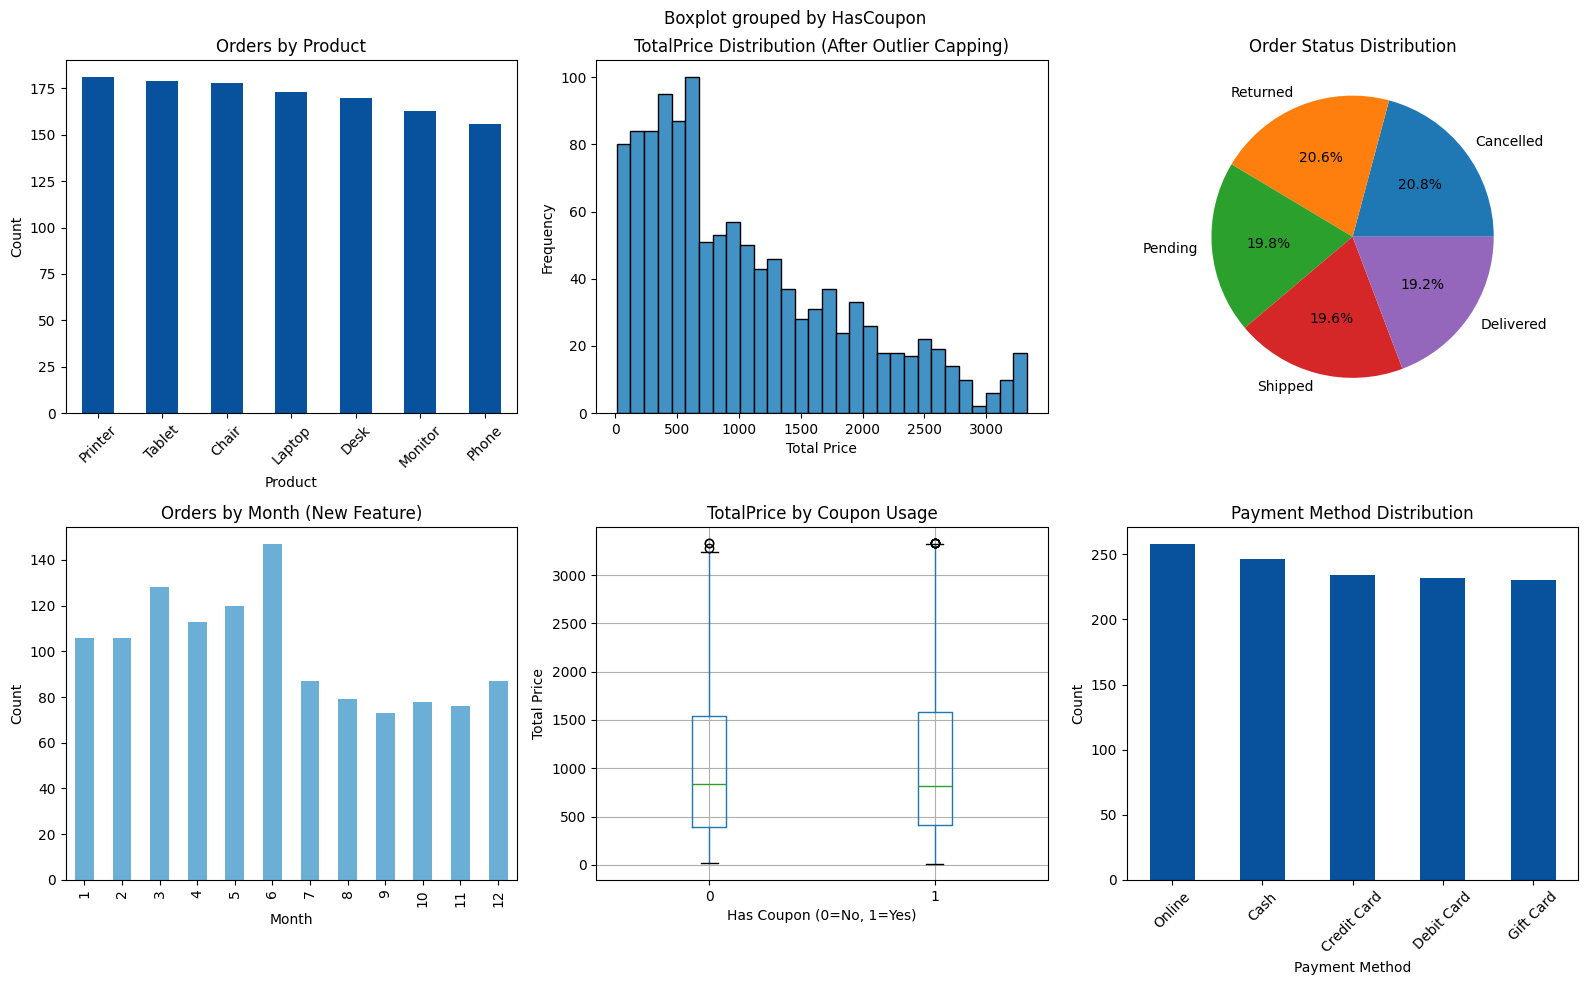

In [37]:
# Visualizations

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Online Store Orders - EDA & Feature Analysis", fontsize=16, fontweight="bold")

# Plot 1: Product distribution
df["Product"].value_counts().plot(kind="bar", ax=axes[0, 0], color="#08519c")
axes[0, 0].set_title("Orders by Product")
axes[0, 0].set_xlabel("Product")
axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis="x", rotation=45)

# Plot 2: TotalPrice distribution (after outlier capping)
axes[0, 1].hist(df["TotalPrice"], bins=30, color="#4292c6", edgecolor="black")
axes[0, 1].set_title("TotalPrice Distribution (After Outlier Capping)")
axes[0, 1].set_xlabel("Total Price")
axes[0, 1].set_ylabel("Frequency")

# Plot 3: Order Status breakdown
df["OrderStatus"].value_counts().plot(kind="pie", ax=axes[0, 2], autopct="%1.1f%%")
axes[0, 2].set_title("Order Status Distribution")
axes[0, 2].set_ylabel("")

# Plot 4: Orders by month (new feature)
df["OrderMonth"].value_counts().sort_index().plot(kind="bar", ax=axes[1, 0], color="#6baed6")
axes[1, 0].set_title("Orders by Month (New Feature)")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Count")

# Plot 5: TotalPrice by coupon usage (new feature)
df.boxplot(column="TotalPrice", by="HasCoupon", ax=axes[1, 1])
axes[1, 1].set_title("TotalPrice by Coupon Usage (New Feature)")
axes[1, 1].set_xlabel("Has Coupon (0=No, 1=Yes)")
axes[1, 1].set_ylabel("Total Price")
plt.sca(axes[1, 1])
plt.title("TotalPrice by Coupon Usage")

# Plot 6: Payment method distribution
df["PaymentMethod"].value_counts().plot(kind="bar", ax=axes[1, 2], color="#08519c")
axes[1, 2].set_title("Payment Method Distribution")
axes[1, 2].set_xlabel("Payment Method")
axes[1, 2].set_ylabel("Count")
axes[1, 2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("EDA_Visualizations.png", dpi=150, bbox_inches="tight")
plt.show()


* This project focused on transforming a raw online store orders dataset (1,200 records) into a mathematically clean, analysis-ready dataset.
* The CouponCode column, which had 25.75% missing values, was treated as structural missingness and filled with "No Coupon" rather than dropped, preserving the full sample size.
* Outliers in Quantity, UnitPrice, ItemsInCart and TotalPrice were detected using the Interquartile Range (IQR) method and neutralized through Winsorization (capping) instead of row deletion, ensuring no data was lost in the process.
* Five new predictive features were engineered from existing columns such as RevenuePerItem, HasCoupon, OrderMonth, OrderYear and IsHighValueOrder to surface patterns not directly visible in the raw data.
* Exploratory visualizations confirmed a fairly balanced spread across products, payment methods and order statuses.
* The final cleaned dataset retains all 1,200 rows with zero missing values, ready to support predictive modeling.



#### Amashi Fernando
Data Science Intern

DecodeLabs Internship (June 10 - July 10 2026)